# 🏗️ 05 — Model 3: Transfer Learning (EfficientNet-B0)

**Why EfficientNet?**
Pretrained on 1.2M ImageNet images. Already knows edges, textures, object parts.

**Strategy:** 2-stage training:
1. Freeze backbone, train classifier head (5 epochs)
2. Unfreeze all, fine-tune with lower LR (25 epochs)

In [1]:
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

CLASSES = ['plastic', 'paper_cardboard', 'metal', 'glass', 'organic', 'e_waste']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0
SEED = 42

PROJECT_ROOT = Path(r'C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification')
DATA_DIR = PROJECT_ROOT / 'notebooks' / 'data'
PROC_DIR = DATA_DIR / 'processed'
CKPT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False

class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        for cls in CLASSES:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                continue
            for img_path in sorted(cls_dir.glob('*.jpg')):
                self.samples.append((img_path, CLASS_TO_IDX[cls]))
        self.targets = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

    def class_counts(self):
        counts = defaultdict(int)
        for _, label in self.samples:
            counts[IDX_TO_CLASS[label]] += 1
        return dict(counts)

def get_dataloaders(proc_dir=PROC_DIR, train_tfm=None, val_tfm=None, batch_size=BATCH_SIZE):
    train_ds = WasteDataset(Path(proc_dir) / 'train', train_tfm)
    val_ds = WasteDataset(Path(proc_dir) / 'val', val_tfm)
    test_ds = WasteDataset(Path(proc_dir) / 'test', val_tfm)

    if len(train_ds) == 0:
        raise ValueError(f'No training images found in {Path(proc_dir) / "train"}')

    counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES)
    weights = 1.0 / (counts[train_ds.targets] + 1e-6)
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    kw = dict(num_workers=0, pin_memory=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, **kw)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kw)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kw)

    print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    return train_loader, val_loader, test_loader

class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

def train_model(model, model_name, train_loader, val_loader, num_epochs=30, lr=1e-3, weight_decay=1e-4, scheduler_type='cosine', label_smoothing=0.1, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    elif scheduler_type == 'onecycle':
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=num_epochs)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    early_stop = EarlyStopping(patience=7)
    best_val_acc = 0.0
    history = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}', flush=True)
    print(f'Model : {model_name}', flush=True)
    print(f'Params: {trainable:,} | Device: {device} | Batch size: {train_loader.batch_size}', flush=True)
    print(f'{"="*60}', flush=True)

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for batch_idx, (imgs, labels) in enumerate(train_loader, start=1):
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loaded', flush=True)
            imgs = imgs.to(device, non_blocking=False)
            labels = labels.to(device, non_blocking=False)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(imgs)
                loss = criterion(out, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_type == 'onecycle':
                scheduler.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
            print(f'  Epoch {epoch:3d}/{num_epochs} | batch {batch_idx:3d}/{len(train_loader)} | loss {loss.item():.4f}', flush=True)

        t_loss = run_loss / total
        t_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=False)
                labels = labels.to(device, non_blocking=False)
                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    out = model(imgs)
                    loss = criterion(out, labels)
                v_loss += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += imgs.size(0)

        v_loss /= v_total
        v_acc = v_correct / v_total

        if scheduler_type != 'onecycle':
            scheduler.step()

        for key, value in zip(history, [t_loss, v_loss, t_acc, v_acc]):
            history[key].append(value)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            CKPT_DIR.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), CKPT_DIR / f'{model_name}_best.pth')

        print(f'Epoch {epoch:3d}/{num_epochs} | Train {t_loss:.4f}/{t_acc:.3f} | Val {v_loss:.4f}/{v_acc:.3f}', flush=True)

        early_stop(v_loss)
        if early_stop.early_stop:
            print(f'Early stopping at epoch {epoch}', flush=True)
            break

    history['best_val_acc'] = best_val_acc
    print(f'Best val acc: {best_val_acc:.4f}', flush=True)
    return history

def evaluate_model(model, model_name, test_loader, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    ckpt = CKPT_DIR / f'{model_name}_best.pth'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'Loaded checkpoint: {ckpt.name}')

    model.eval().to(device)
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = model(imgs.to(device))
            probs = torch.softmax(out, 1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f'\n{model_name} - Test Results')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f} Recall: {r:.4f} F1: {f1:.4f}')
    print('\nPer-class report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))

    return dict(model=model_name, accuracy=acc, precision=p, recall=r, f1=f1, confusion_matrix=cm, preds=all_preds, labels=all_labels, probs=all_probs)

def plot_training_curves(history, model_name, save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(epochs, history['val_loss'], 'r-o', ms=3, label='Val')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax2.plot(epochs, history['train_acc'], 'b-o', ms=3, label='Train')
    ax2.plot(epochs, history['val_acc'], 'r-o', ms=3, label='Val')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(alpha=0.3)
    plt.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f'curves_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(cm, model_name, save=True):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIGURES_DIR / f'cm_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

class EfficientNetModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def freeze_backbone(self):
        for param in self.backbone.features.parameters():
            param.requires_grad = False

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

set_seed()
if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is not available in this notebook kernel.')
DEVICE = torch.device('cuda:0')
torch.backends.cudnn.benchmark = True
print(f'Device: {DEVICE} - {torch.cuda.get_device_name(0)}')
print(f'Using data: {PROC_DIR}')

train_loader, val_loader, test_loader = get_dataloaders(
    proc_dir=PROC_DIR,
    train_tfm=train_transforms,
    val_tfm=val_test_transforms,
)

Device: cuda:0 - NVIDIA GeForce RTX 3070 Laptop GPU
Using data: C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\notebooks\data\processed
Train: 1,888 | Val: 401 | Test: 412


In [2]:
print('Loading EfficientNet-B0 ImageNet weights...', flush=True)
model = EfficientNetModel().to(DEVICE)
print('EfficientNet loaded.', flush=True)
print(f'Model device: {next(model.parameters()).device}')
print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')

Loading EfficientNet-B0 ImageNet weights...
EfficientNet loaded.
Model device: cuda:0
Total params: 4,015,234


In [3]:
# Stage 1 — head only
model.freeze_backbone()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 trainable params: {trainable:,}')
h1 = train_model(model,'efficientnet_stage1',train_loader,val_loader,
                 num_epochs=5,lr=1e-3,device=DEVICE)

Stage 1 trainable params: 7,686

Model : efficientnet_stage1
Params: 7,686 | Device: cuda:0 | Batch size: 8


C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


  Epoch   1/5 | batch   1/236 | loaded


C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  Epoch   1/5 | batch   1/236 | loss 1.7602
  Epoch   1/5 | batch   2/236 | loaded
  Epoch   1/5 | batch   2/236 | loss 1.8032
  Epoch   1/5 | batch   3/236 | loaded
  Epoch   1/5 | batch   3/236 | loss 1.6572
  Epoch   1/5 | batch   4/236 | loaded
  Epoch   1/5 | batch   4/236 | loss 1.8483
  Epoch   1/5 | batch   5/236 | loaded
  Epoch   1/5 | batch   5/236 | loss 1.9596
  Epoch   1/5 | batch   6/236 | loaded
  Epoch   1/5 | batch   6/236 | loss 1.8960
  Epoch   1/5 | batch   7/236 | loaded
  Epoch   1/5 | batch   7/236 | loss 1.6881
  Epoch   1/5 | batch   8/236 | loaded
  Epoch   1/5 | batch   8/236 | loss 1.8467
  Epoch   1/5 | batch   9/236 | loaded
  Epoch   1/5 | batch   9/236 | loss 1.8039
  Epoch   1/5 | batch  10/236 | loaded
  Epoch   1/5 | batch  10/236 | loss 1.6930
  Epoch   1/5 | batch  11/236 | loaded
  Epoch   1/5 | batch  11/236 | loss 1.7746
  Epoch   1/5 | batch  12/236 | loaded
  Epoch   1/5 | batch  12/236 | loss 1.7701
  Epoch   1/5 | batch  13/236 | loaded
  Ep

C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:193: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch   1/5 | Train 1.3100/0.594 | Val 1.0232/0.758
  Epoch   2/5 | batch   1/236 | loaded
  Epoch   2/5 | batch   1/236 | loss 1.0051
  Epoch   2/5 | batch   2/236 | loaded
  Epoch   2/5 | batch   2/236 | loss 1.1568
  Epoch   2/5 | batch   3/236 | loaded
  Epoch   2/5 | batch   3/236 | loss 1.1076
  Epoch   2/5 | batch   4/236 | loaded
  Epoch   2/5 | batch   4/236 | loss 1.1402
  Epoch   2/5 | batch   5/236 | loaded
  Epoch   2/5 | batch   5/236 | loss 1.1121
  Epoch   2/5 | batch   6/236 | loaded
  Epoch   2/5 | batch   6/236 | loss 1.2158
  Epoch   2/5 | batch   7/236 | loaded
  Epoch   2/5 | batch   7/236 | loss 1.1563
  Epoch   2/5 | batch   8/236 | loaded
  Epoch   2/5 | batch   8/236 | loss 0.8782
  Epoch   2/5 | batch   9/236 | loaded
  Epoch   2/5 | batch   9/236 | loss 1.3840
  Epoch   2/5 | batch  10/236 | loaded
  Epoch   2/5 | batch  10/236 | loss 0.9847
  Epoch   2/5 | batch  11/236 | loaded
  Epoch   2/5 | batch  11/236 | loss 0.8350
  Epoch   2/5 | batch  12/236 | loa

In [4]:
# Stage 2 — full fine-tune (lower LR)
model.unfreeze_all()
print(f'Stage 2 trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
h2 = train_model(model,'efficientnet_b0',train_loader,val_loader,
                 num_epochs=25,lr=1e-4,scheduler_type='cosine',device=DEVICE)
# Merge histories for one continuous plot
full_history = {k: h1[k]+h2[k] for k in ('train_loss','val_loss','train_acc','val_acc')}

Stage 2 trainable params: 4,015,234

Model : efficientnet_b0
Params: 4,015,234 | Device: cuda:0 | Batch size: 8


C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


  Epoch   1/25 | batch   1/236 | loaded


C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  Epoch   1/25 | batch   1/236 | loss 0.6189
  Epoch   1/25 | batch   2/236 | loaded
  Epoch   1/25 | batch   2/236 | loss 0.9116
  Epoch   1/25 | batch   3/236 | loaded
  Epoch   1/25 | batch   3/236 | loss 0.9015
  Epoch   1/25 | batch   4/236 | loaded
  Epoch   1/25 | batch   4/236 | loss 0.8695
  Epoch   1/25 | batch   5/236 | loaded
  Epoch   1/25 | batch   5/236 | loss 0.9948
  Epoch   1/25 | batch   6/236 | loaded
  Epoch   1/25 | batch   6/236 | loss 1.4038
  Epoch   1/25 | batch   7/236 | loaded
  Epoch   1/25 | batch   7/236 | loss 0.9685
  Epoch   1/25 | batch   8/236 | loaded
  Epoch   1/25 | batch   8/236 | loss 1.1806
  Epoch   1/25 | batch   9/236 | loaded
  Epoch   1/25 | batch   9/236 | loss 0.9365
  Epoch   1/25 | batch  10/236 | loaded
  Epoch   1/25 | batch  10/236 | loss 0.6883
  Epoch   1/25 | batch  11/236 | loaded
  Epoch   1/25 | batch  11/236 | loss 0.9510
  Epoch   1/25 | batch  12/236 | loaded
  Epoch   1/25 | batch  12/236 | loss 0.9569
  Epoch   1/25 | bat

C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:193: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch   1/25 | Train 0.9565/0.758 | Val 0.7558/0.873
  Epoch   2/25 | batch   1/236 | loaded
  Epoch   2/25 | batch   1/236 | loss 1.0795
  Epoch   2/25 | batch   2/236 | loaded
  Epoch   2/25 | batch   2/236 | loss 0.8442
  Epoch   2/25 | batch   3/236 | loaded
  Epoch   2/25 | batch   3/236 | loss 0.7982
  Epoch   2/25 | batch   4/236 | loaded
  Epoch   2/25 | batch   4/236 | loss 1.2231
  Epoch   2/25 | batch   5/236 | loaded
  Epoch   2/25 | batch   5/236 | loss 0.9305
  Epoch   2/25 | batch   6/236 | loaded
  Epoch   2/25 | batch   6/236 | loss 0.8513
  Epoch   2/25 | batch   7/236 | loaded
  Epoch   2/25 | batch   7/236 | loss 0.8295
  Epoch   2/25 | batch   8/236 | loaded
  Epoch   2/25 | batch   8/236 | loss 0.8055
  Epoch   2/25 | batch   9/236 | loaded
  Epoch   2/25 | batch   9/236 | loss 1.0406
  Epoch   2/25 | batch  10/236 | loaded
  Epoch   2/25 | batch  10/236 | loss 0.8058
  Epoch   2/25 | batch  11/236 | loaded
  Epoch   2/25 | batch  11/236 | loss 0.6588
  Epoch   2/

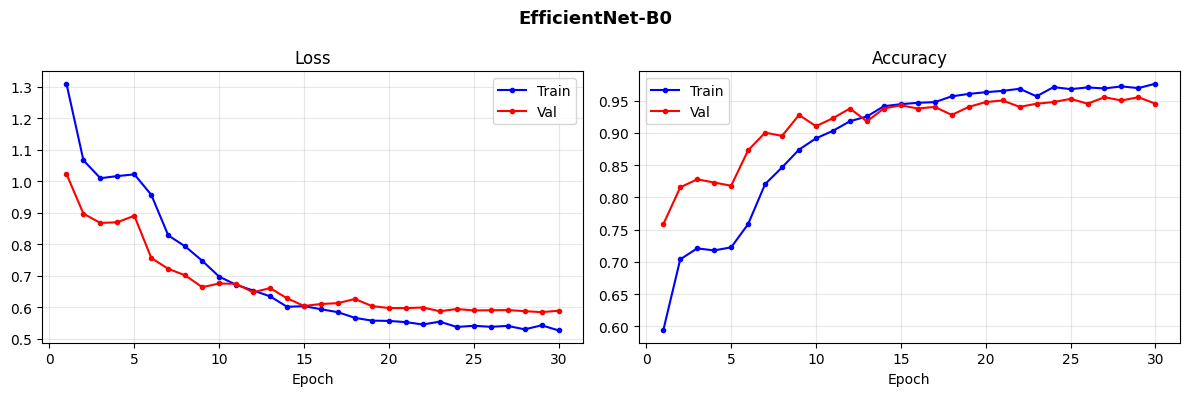

In [5]:
plot_training_curves(full_history, 'EfficientNet-B0')

C:\Users\msfir\AppData\Local\Temp\ipykernel_25308\3433330336.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device

Loaded checkpoint: efficientnet_b0_best.pth

efficientnet_b0 - Test Results
Accuracy : 0.9442
Precision: 0.9473 Recall: 0.9442 F1: 0.9446

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.97      0.88      0.92        66
paper_cardboard       0.98      0.96      0.97       136
          metal       0.84      0.96      0.90        72
          glass       0.96      0.92      0.94        71
        organic       0.93      1.00      0.97        14
        e_waste       0.98      1.00      0.99        53

       accuracy                           0.94       412
      macro avg       0.94      0.95      0.95       412
   weighted avg       0.95      0.94      0.94       412



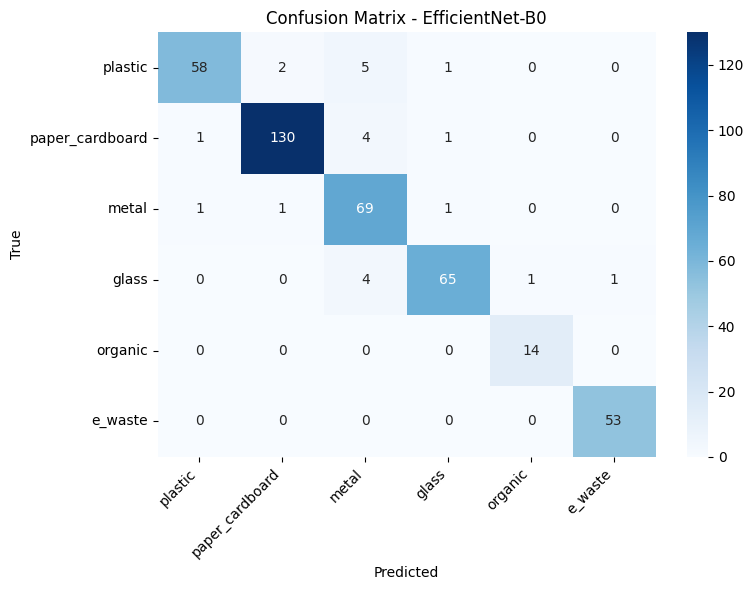

In [6]:
results = evaluate_model(model,'efficientnet_b0',test_loader,device=DEVICE)
plot_confusion_matrix(results['confusion_matrix'],'EfficientNet-B0')